# 05 · Volume & salience — how much, and how prominent

Raw volume can mislead: a sub that simply grew will *look* like rising interest.
So alongside raw counts we compute **share of conversation** = congestion-pricing
items ÷ **all** activity in that sub/period (denominators from the unfiltered
18.4M-row files). That isolates genuine attention.

Also: **off-topic share** (filter precision signal) and the **day-part profile**
(when does this conversation happen, NYC-local).

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

In [2]:
sh    = A.add_geo(A.load_rollup("stance_hourly"))
denom = A.add_geo(A.load_rollup("denom_hourly"))
# topic items per month (all stances incl off-topic = everything the filter matched)
topic_m = (sh.assign(period=A.time_bucket(sh.et_date,"monthly"))
             .groupby("period")["n"].sum().rename("n").reset_index())
total_m = (denom.assign(period=A.time_bucket(denom.et_date,"monthly"))
             .groupby("period")["n"].sum().rename("n").reset_index())
soc = A.share_of_conversation(topic_m, total_m, on=("period",))
soc.tail(4)

,period,n_topic,n_total,share_topic
37,2026-01-01,8413,552159,0.015237
38,2026-02-01,6614,482594,0.013705
39,2026-03-01,8956,510513,0.017543
40,2026-04-01,7650,461631,0.016572


### Raw volume vs share of conversation (monthly)

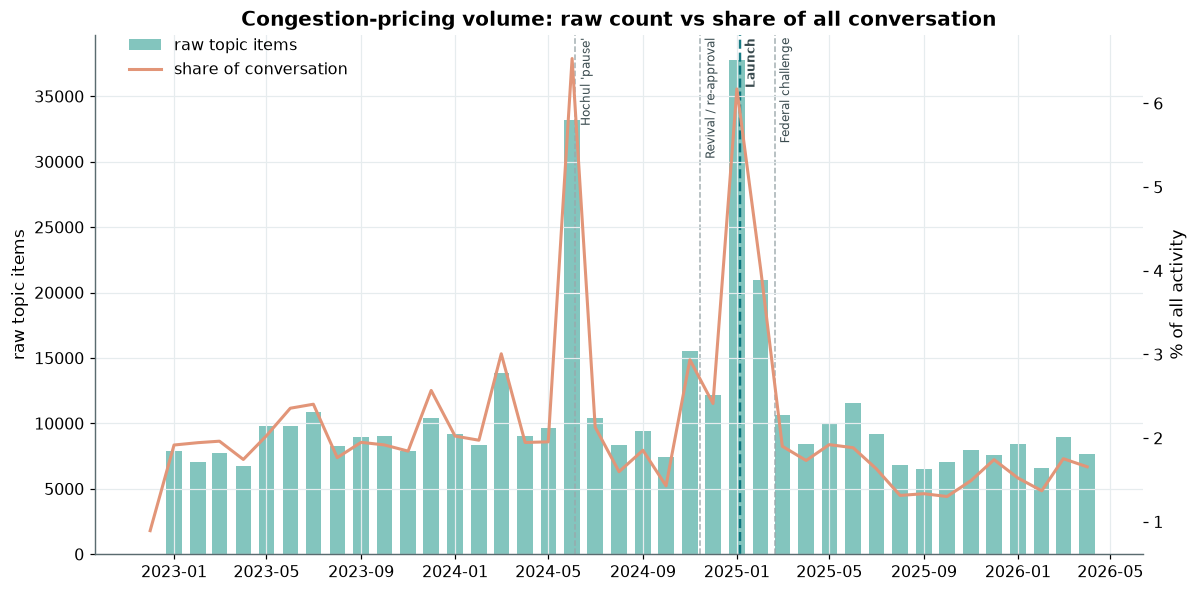

In [3]:
fig, ax1 = plt.subplots()
ax1.bar(topic_m.period, topic_m.n, width=20, color=C.PALETTE["teal"], label="raw topic items")
ax1.set_ylabel("raw topic items"); A.annotate_events(ax1)
ax2 = ax1.twinx()
ax2.plot(soc.period, soc.share_topic*100, color=C.PALETTE["terracotta"], lw=2, label="share of conversation")
ax2.set_ylabel("% of all activity"); ax2.grid(False)
ax1.set_title("Congestion-pricing volume: raw count vs share of all conversation")
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.95))
plt.tight_layout(); plt.show()

### Share of conversation by geo tier (are some places more preoccupied?)

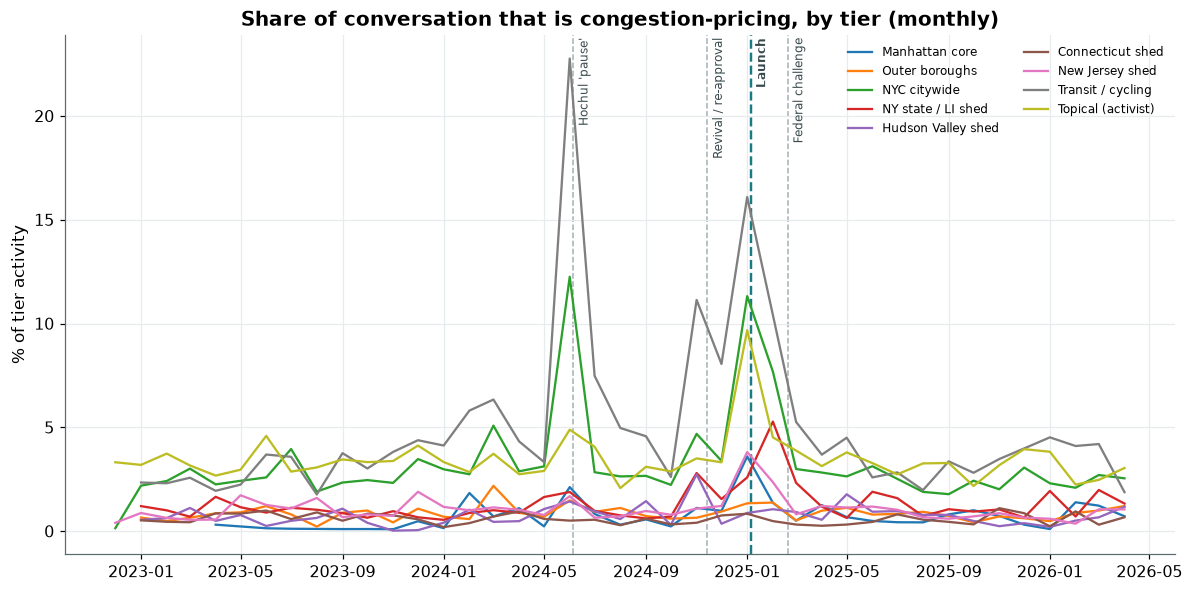

In [4]:
topic_gt = (sh.assign(period=A.time_bucket(sh.et_date,"monthly"))
              .groupby(["period","geo_tier"])["n"].sum().rename("n").reset_index())
total_gt = (denom.assign(period=A.time_bucket(denom.et_date,"monthly"))
              .groupby(["period","geo_tier"])["n"].sum().rename("n").reset_index())
socg = A.share_of_conversation(topic_gt, total_gt, on=("period","geo_tier"))
fig, ax = plt.subplots()
for tier in [t for t in C.GEO_TIER_ORDER if t in socg.geo_tier.unique()]:
    w = socg[(socg.geo_tier==tier)].sort_values("period")
    ax.plot(w.period, w.share_topic*100, lw=1.5, label=tier)
ax.set_title("Share of conversation that is congestion-pricing, by tier (monthly)")
ax.set_ylabel("% of tier activity"); ax.legend(ncol=2, fontsize=8)
A.annotate_events(ax)
plt.tight_layout(); plt.show()

### Day-part profile — when does this conversation happen? (NYC-local)

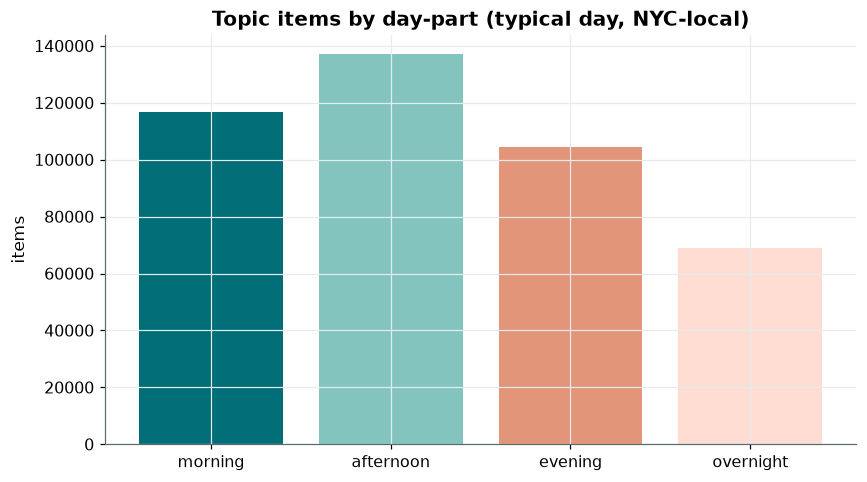

Day-part definitions (edit in config.py): {'morning': (6, 12), 'afternoon': (12, 17), 'evening': (17, 22), 'overnight': (22, 6)}


In [5]:
dp = A.aggregate(sh, "daypart", by=(), stance_col="stance")
dp = dp.groupby("daypart")["n"].sum().reindex(C.DAYPART_ORDER)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(dp.index, dp.values, color=[C.PALETTE["deep_teal"],C.PALETTE["teal"],C.PALETTE["terracotta"],C.PALETTE["pink"]])
ax.set_title("Topic items by day-part (typical day, NYC-local)"); ax.set_ylabel("items")
plt.tight_layout(); plt.show()
print("Day-part definitions (edit in config.py):", C.DAYPARTS)

**Note:** raw and share-of-conversation can diverge — that divergence *is* the finding. Volume spikes that are flat in share are just the whole sub being busy; spikes in *share* are real attention shifts.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>